In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
import scipy.stats as stats

In [7]:
df=pd.read_csv(r"C:\Users\Purbasha Dey\Desktop\PYTHON\Housing.csv")

LOADING DATASET

In [8]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [9]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [11]:
df.shape

(545, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


DATA CLEANING


In [14]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

UNIVARIATE AND BIVARIATE ANALYSIS

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\2531786219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


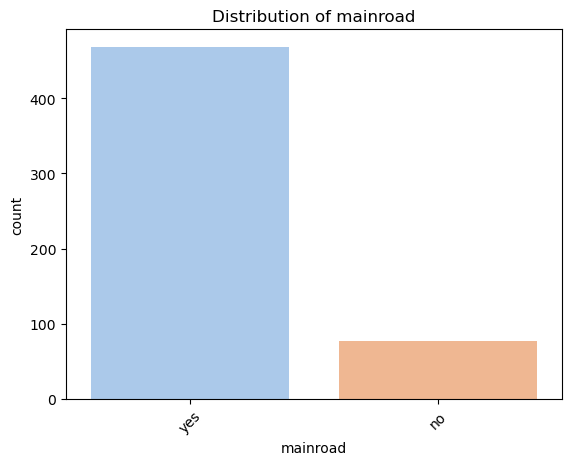

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\2531786219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


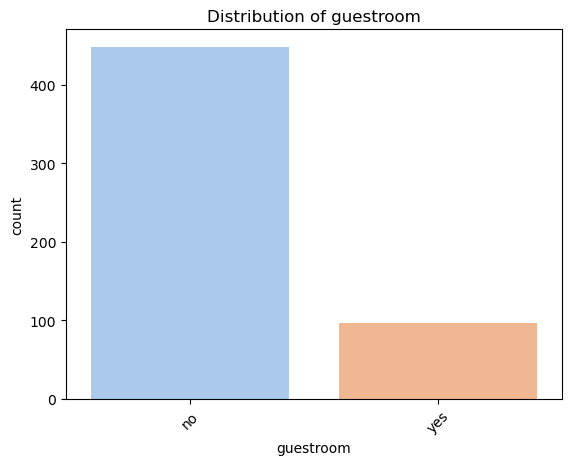

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\2531786219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


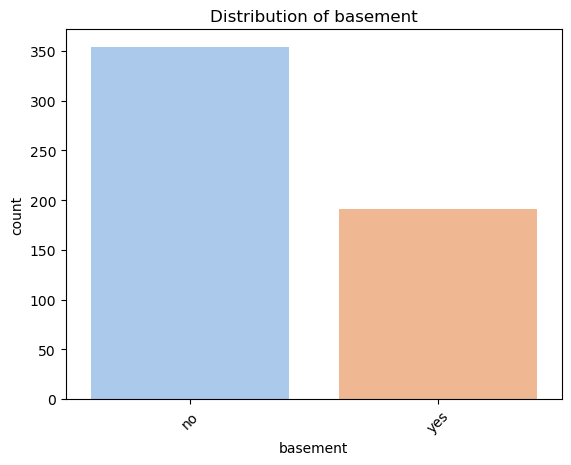

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\2531786219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


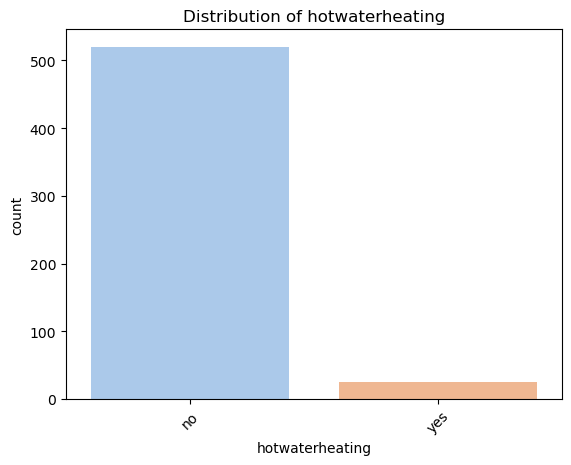

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\2531786219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


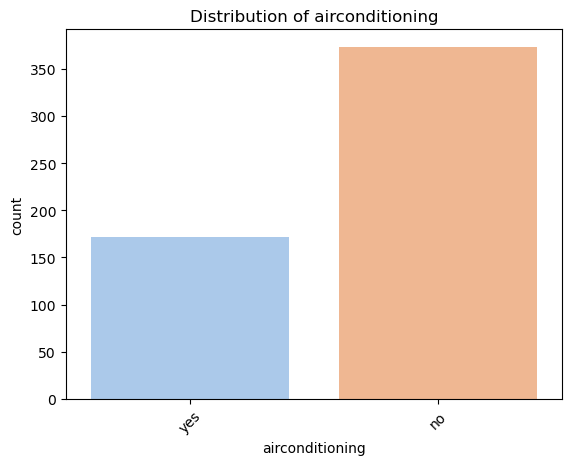

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\2531786219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


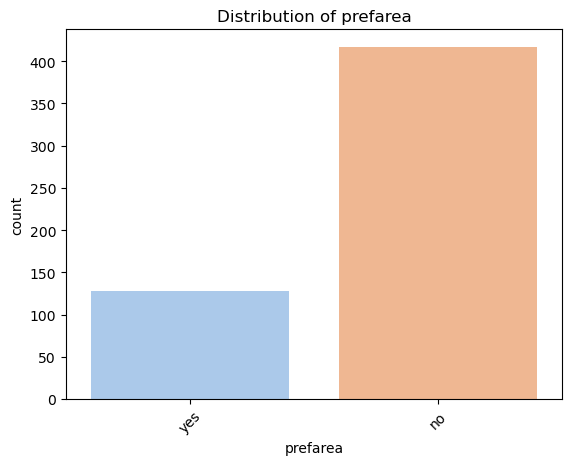

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\2531786219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


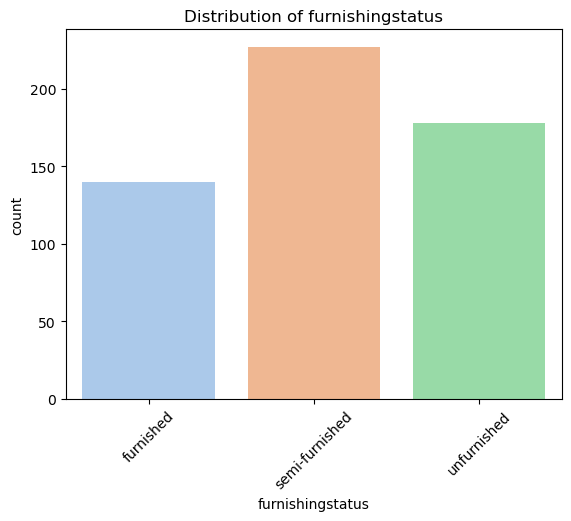

In [19]:
feautures = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
numerical = ['area','bedrooms','bathrooms','stories','parking']

for col in feautures:
    sns.countplot(x=col, data=df, palette='pastel')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

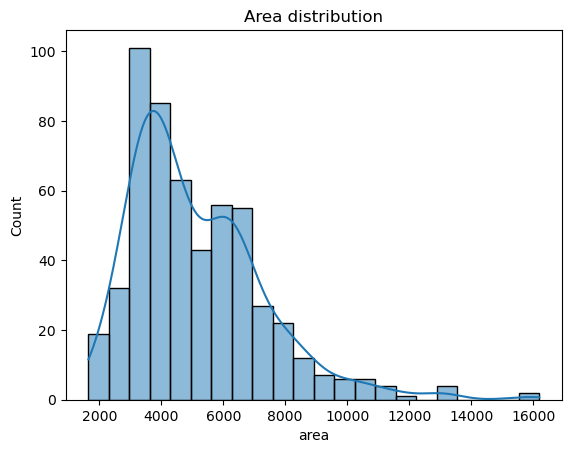

In [22]:
sns.histplot(df['area'].dropna(),kde = True)
plt.title('Area distribution')
plt.show()

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\3061934520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


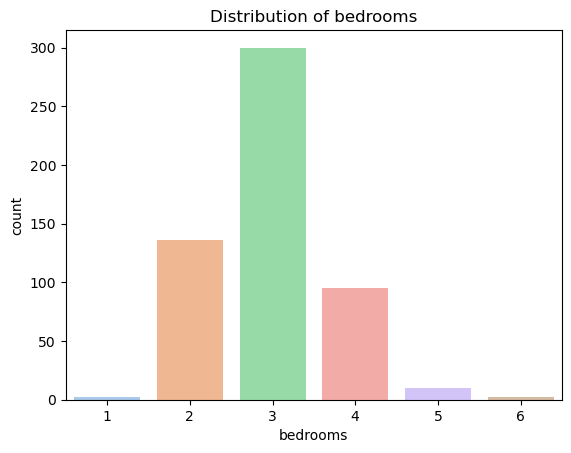

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\3061934520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


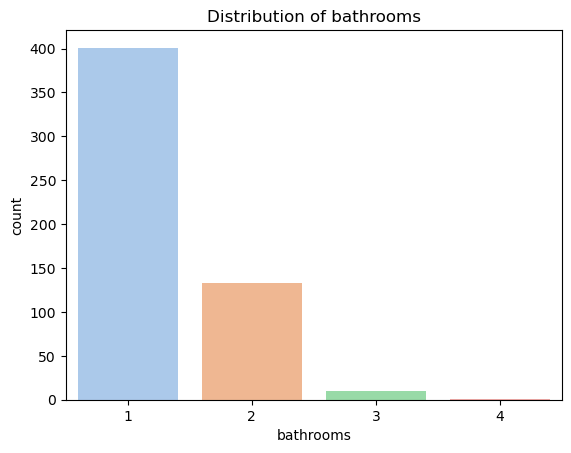

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\3061934520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


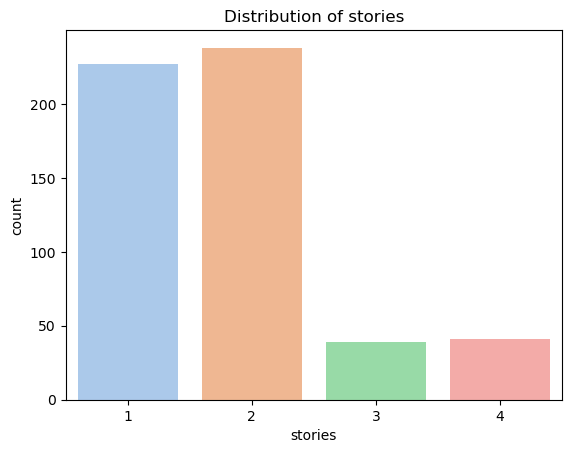

C:\Users\Purbasha Dey\AppData\Local\Temp\ipykernel_20620\3061934520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='pastel')


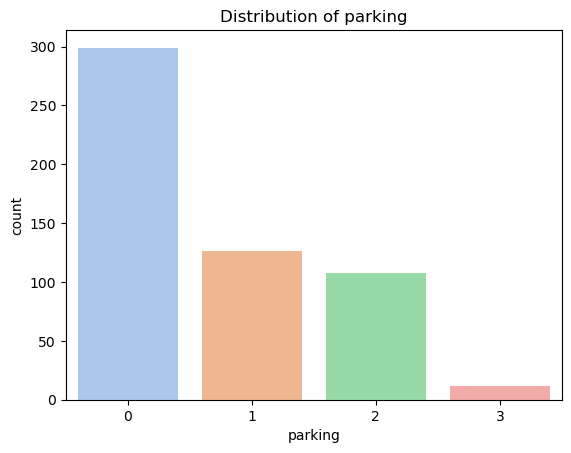

In [24]:
for col in numerical:
    if col != 'area':
      sns.countplot(x=col, data=df, palette='pastel')
      plt.title(f'Distribution of {col}')
      plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

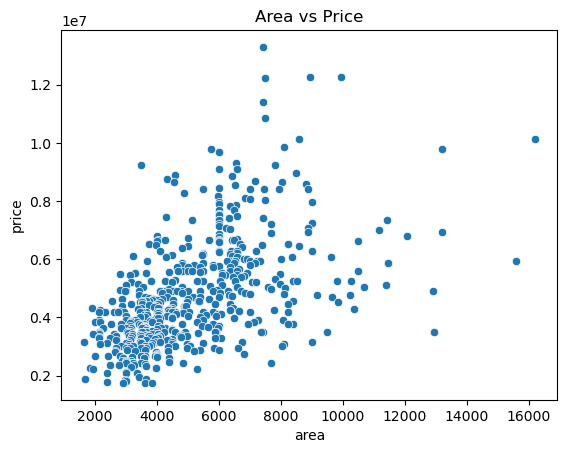

In [26]:
sns.scatterplot(x = 'area' , y='price',data =df)
plt.title('Area vs Price')
plt.show

# Insights
* Many houses are clustered in the cheap - moderate range
* After that the pricesof the houses increase rapidly due the dependences of multiple features

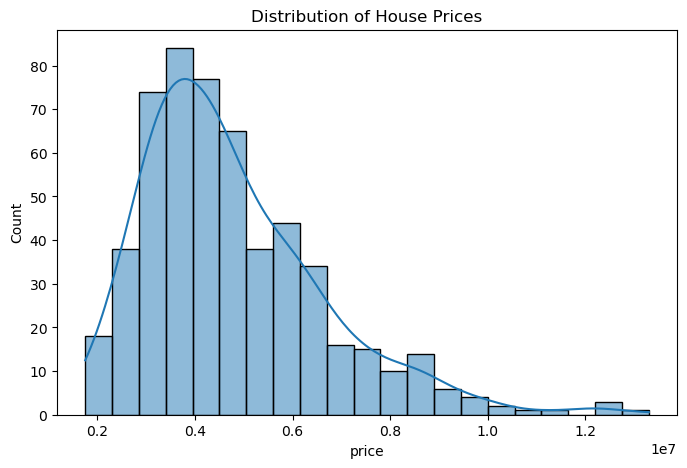

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of House Prices")

plt.show()

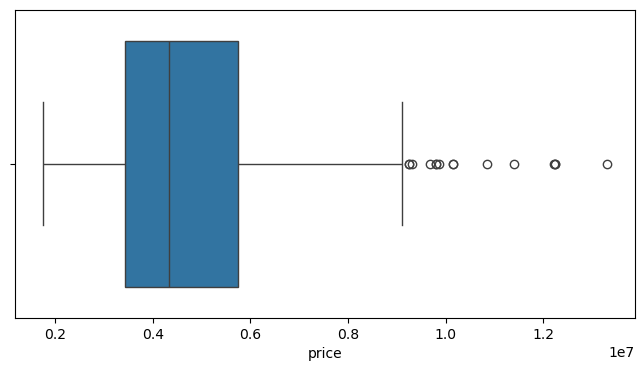

In [28]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["price"])

plt.show()


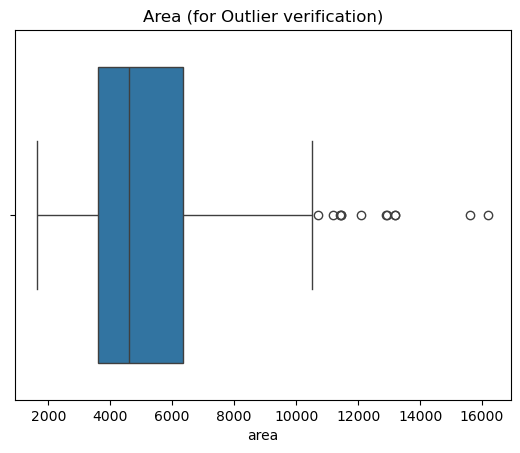

In [34]:
sns.boxplot(x = df[f'area'])
plt.title('Area (for Outlier verification)')
plt.show()

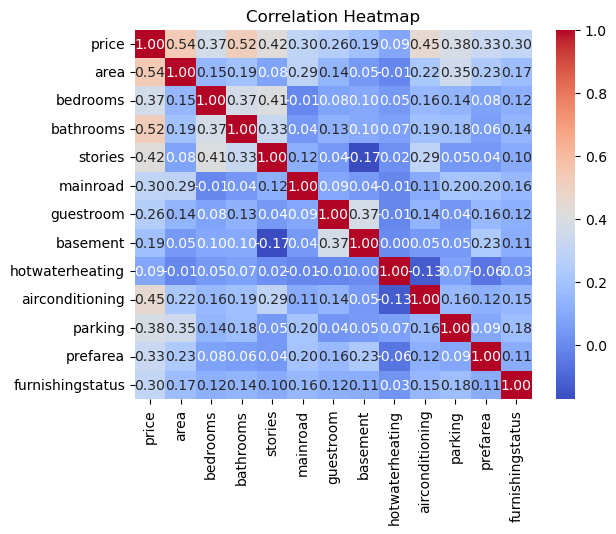

In [37]:
copy = df.copy()

# Binary mappings
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    copy[col] = copy[col].map({'yes': 1, 'no': 0})

# Map furnishing status
copy['furnishingstatus'] = copy['furnishingstatus'].map({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})

sns.heatmap(copy.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Insights
* Price shows a strong positive correlation with area (0.54), bathrooms (0.52), and air conditioning (0.45), while it has a noticeable negative correlation with the basement feature (-0.19).

* Area is moderately linked to parking (0.35) and price (0.54), whereas the remaining variables exhibit generally weak interrelationships.

* There are no strong negative correlations in the dataset—most associations are either weak or positively inclined, with the exception of the negative link between basement and price

In [39]:
binary_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_cols:
    df[col] = df[col].map({"yes":1,"no":0})

In [44]:
X = df.drop("price", axis=1)

y = df["price"]

In [60]:
df[binary_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [61]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [62]:
df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True
)

In [63]:
X = df.drop("price", axis=1)
y = df["price"]

In [65]:
X = df.drop("price", axis=1)
y = df["price"]

In [66]:
X = X.astype(float)

In [67]:
print(X.isnull().sum())

area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64


In [68]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})

vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

                            Feature        VIF
1                          bedrooms  16.652387
2                         bathrooms   9.417643
0                              area   8.276447
3                           stories   7.880730
4                          mainroad   6.884806
11  furnishingstatus_semi-furnished   2.386831
6                          basement   2.019858
12     furnishingstatus_unfurnished   2.008632
9                           parking   1.986400
8                   airconditioning   1.767753
10                         prefarea   1.494211
5                         guestroom   1.473234
7                   hotwaterheating   1.091568


INSIGHT-
Bedrooms has a high VIF (16.65), indicating severe multicollinearity.
bathrooms, area, stories, and mainroad have moderate multicollinearity (VIF between 5 and 10).
The remaining variables have acceptable VIF values (<5), suggesting low multicollinearity.

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
y_pred = model.predict(X_test)

In [74]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 970043.4039201634
MSE : 1754318687330.6628
RMSE: 1324506.9600914384
R² : 0.6529242642153186


In [75]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)

model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Tue, 04 Aug 2026   Prob (F-statistic):          9.07e-123
Time:                        21:42:55   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

Insight

Although the number of bedrooms is often expected to influence house prices, it is not statistically significant in this model. This may be because its effect is already captured by related variables such as area and bathrooms, which is consistent with the multicollinearity observed during the VIF analysis.

Overall Model

The Linear Regression model demonstrates good explanatory power with an R² of 68.2% and an Adjusted R² of 67.4%. The overall regression model is statistically significant (F-test p < 0.001), indicating that the selected predictors collectively explain house prices well.

Significant Predictors

Variables such as area, bathrooms, stories, parking, air conditioning, preferred area, basement, and hot water heating significantly influence house prices (p < 0.05).

Insignificant Predictors

bedrooms and furnishingstatus_semi-furnished are not statistically significant. This suggests that these variables do not provide additional explanatory power after accounting for the other predictors. The insignificance of bedrooms may also be influenced by multicollinearity.

Model Assumptions

The model shows evidence of multicollinearity (high VIF and condition number), and the residuals deviate from normality according to the Omnibus and Jarque-Bera tests. These findings indicate that the assumptions of classical linear regression are not fully satisfied.

In [77]:
X_new = df.drop(
    columns=[
        "price",
        "bedrooms",
        "furnishingstatus_semi-furnished"
    ]
)

In [78]:
y = df["price"]

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y,
    test_size=0.20,
    random_state=42
)

In [80]:
from sklearn.linear_model import LinearRegression

model_new = LinearRegression()

model_new.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


CHECK LINEAR REGRESSION ASSUMPTIONS

In [81]:
y_pred = model_new.predict(X_test)

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 965607.8769729899
RMSE: 1324523.224678472
R² : 0.6529157401707619


In [86]:
residuals = y_test - y_pred

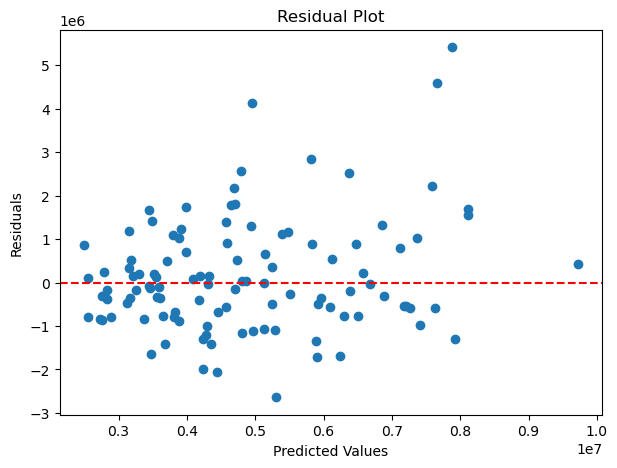

In [87]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

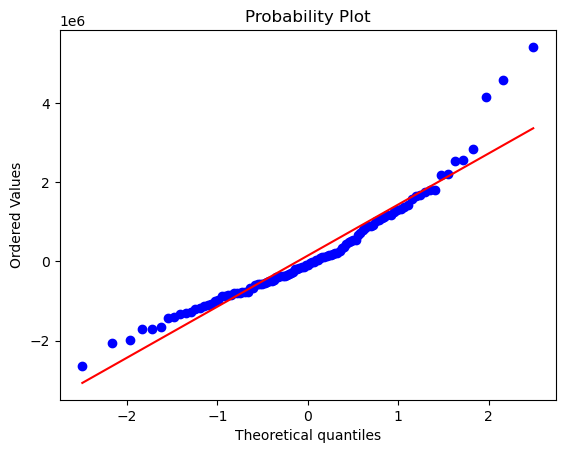

In [88]:
stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.show()

In [89]:
X_sm = sm.add_constant(X)

ols_model = sm.OLS(y, X_sm).fit()

bp = het_breuschpagan(
    ols_model.resid,
    ols_model.model.exog
)

labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

print(dict(zip(labels, bp)))

{'LM Statistic': np.float64(68.41642155741293), 'LM p-value': np.float64(1.5685819403907652e-09), 'F Statistic': np.float64(5.863709550525472), 'F p-value': np.float64(3.493872033548088e-10)}


In [90]:

dw = durbin_watson(
    ols_model.resid
)

print(dw)

1.2093956266264962


In [91]:
print(model.intercept_)

260032.35760740936


In [92]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


Regression Diagnostics: The residual analysis suggests that the linear relationship between the predictors and house price is reasonably captured by the model. However, the Q-Q plot indicates deviations from normality at the tails, suggesting the presence of outliers. The Breusch-Pagan test confirms heteroscedasticity (p < 0.05), indicating that the variance of the residuals is not constant. Additionally, the Durbin-Watson statistic (1.20) suggests mild positive autocorrelation among the residuals. While the model provides useful predictive insights, these diagnostic results indicate that some classical linear regression assumptions are not fully satisfied.

In [93]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower) | (df["price"] > upper)]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 15


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


I recommend we do not remove the outliers from this dataset. Instead, let's build a second linear regression model using log(price). Comparing the original model with the log-transformed model is a common and professional approach in house price modeling and often leads to better-behaved residuals and improved regression diagnostics.

Insight: The target variable (price) exhibits a right-skewed distribution, with most observations concentrated in the lower price range and a few high-priced houses forming a long right tail. This indicates the presence of extreme values and suggests that a logarithmic transformation of the target variable may improve normality and stabilize the variance for linear regression

In [95]:
df["log_price"] = np.log(df["price"])

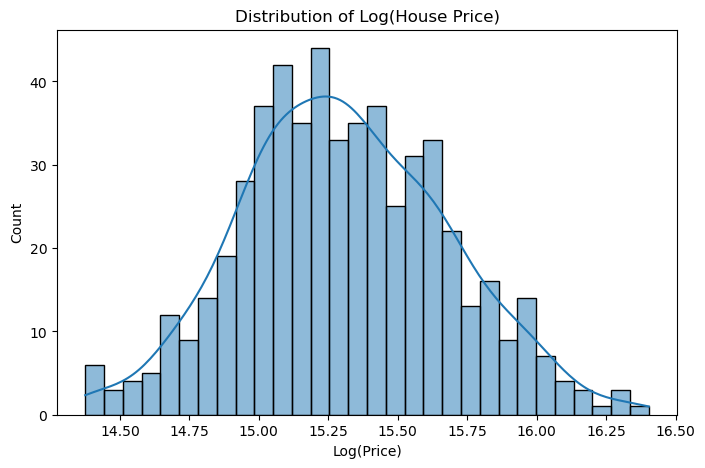

In [96]:
plt.figure(figsize=(8,5))
sns.histplot(df["log_price"], bins=30, kde=True)

plt.title("Distribution of Log(House Price)")
plt.xlabel("Log(Price)")
plt.show()

In [97]:
X = df.drop(
    columns=[
        "price",
        "log_price",
        "bedrooms",
        "furnishingstatus_semi-furnished"
    ]
)

y = df["log_price"]

In [98]:
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [100]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [101]:
y_pred = model.predict(X_test)

In [102]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

MAE : 0.20144030421770504
RMSE: 0.25352061849238705
R² : 0.6671338453361019


In [103]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)

ols_model = sm.OLS(y, X_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.690
Method:                 Least Squares   F-statistic:                     111.0
Date:                Tue, 04 Aug 2026   Prob (F-statistic):          4.62e-130
Time:                        22:23:08   Log-Likelihood:                 90.417
No. Observations:                 545   AIC:                            -156.8
Df Residuals:                     533   BIC:                            -105.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

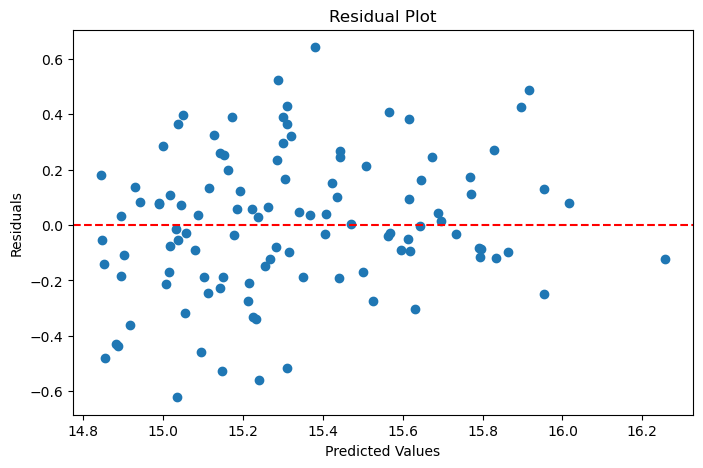

In [104]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

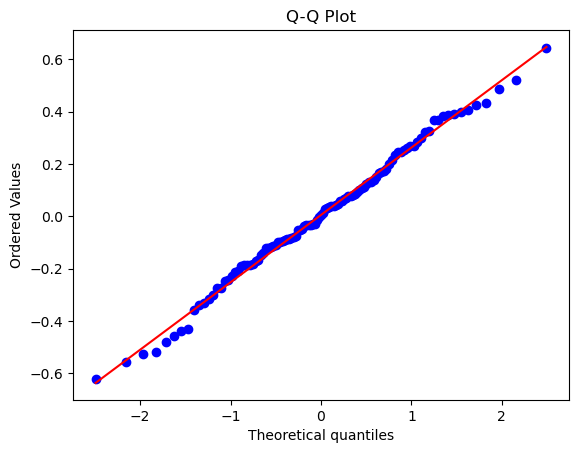

In [105]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [106]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp = het_breuschpagan(ols_model.resid, ols_model.model.exog)

labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

print(dict(zip(labels, bp)))

{'LM Statistic': np.float64(25.4123808418842), 'LM p-value': np.float64(0.007929817954274394), 'F Statistic': np.float64(2.3698512381923904), 'F p-value': np.float64(0.007278189461077635)}


A logarithmic transformation was applied to the target variable (price) to reduce skewness and improve compliance with the assumptions of linear regression. Compared with the original model, the transformed model achieved higher R² and Adjusted R² values, while the residuals became approximately normally distributed, as confirmed by the Q-Q plot and Jarque-Bera test. Although the Breusch-Pagan test indicates that some heteroscedasticity remains, its severity was reduced after the transformation. Overall, the log-linear regression model provides better statistical properties and predictive performance, making it the preferred model for this analysis.